In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch


In [2]:
# Base path
data_path = r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\bidmc_csv"

fs = 125  # sampling frequency
window_sec = 30
stride_sec = 15

window_samples = window_sec * fs
stride_samples = stride_sec * fs


In [3]:
def compute_window_rr(breaths_df, start_sample, end_sample):
    breaths_df.columns = breaths_df.columns.str.strip()
    
    ann1 = breaths_df.iloc[:, 0].dropna().values
    ann2 = breaths_df.iloc[:, 1].dropna().values
    
    # Count breaths inside window
    count1 = np.sum((ann1 >= start_sample) & (ann1 < end_sample))
    count2 = np.sum((ann2 >= start_sample) & (ann2 < end_sample))
    
    avg_count = (count1 + count2) / 2
    
    # RR = breaths per minute
    rr = avg_count / (window_sec / 60)
    
    return rr


In [4]:
all_windows = []
all_labels = []
all_subjects = []

for i in tqdm(range(1, 54)):
    
    # Load signals
    signals = pd.read_csv(os.path.join(data_path, f"bidmc_{i:02d}_Signals.csv"))
    signals.columns = signals.columns.str.strip()
    
    # Load breaths
    breaths = pd.read_csv(os.path.join(data_path, f"bidmc_{i:02d}_Breaths.csv"))
    
    ppg = signals['PLETH'].values
    total_samples = len(ppg)
    
    start = 0
    
    while start + window_samples <= total_samples:
        
        end = start + window_samples
        
        # Compute RR label
        rr = compute_window_rr(breaths, start, end)
        
        # Filter unrealistic RR
        if 5 <= rr <= 40:
            
            window_signal = ppg[start:end]
            
            all_windows.append(window_signal)
            all_labels.append(rr)
            all_subjects.append(i)
        
        start += stride_samples


100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [00:06<00:00,  8.52it/s]


In [5]:
X = np.array(all_windows)
y = np.array(all_labels)
subjects = np.array(all_subjects)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique subjects:", len(np.unique(subjects)))
print("RR range:", y.min(), "to", y.max())


X shape: (1638, 3750)
y shape: (1638,)
Unique subjects: 53
RR range: 6.0 to 26.0


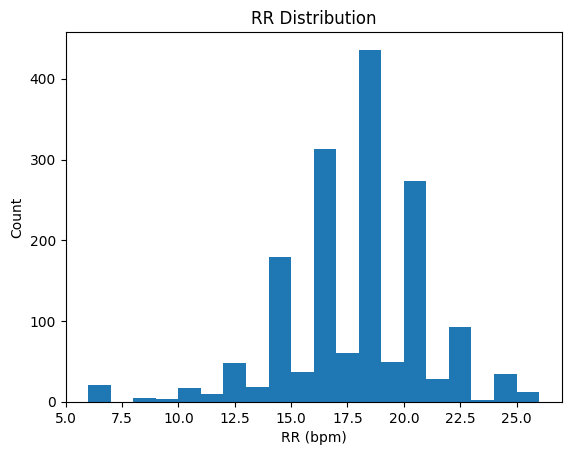

Mean RR: 17.347374847374848
Std RR: 3.1463434706906717


In [6]:
import matplotlib.pyplot as plt

plt.hist(y, bins=20)
plt.xlabel("RR (bpm)")
plt.ylabel("Count")
plt.title("RR Distribution")
plt.show()

print("Mean RR:", np.mean(y))
print("Std RR:", np.std(y))


In [7]:
def bandpass_filter(signal, lowcut=0.1, highcut=0.4, fs=125, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    
    return filtered


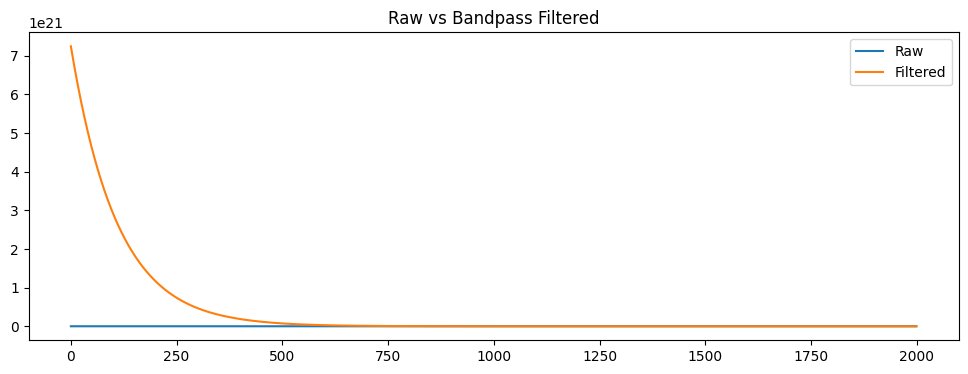

In [8]:
sample_signal = X[0]   # replace with your signal array
filtered_signal = bandpass_filter(sample_signal, fs=fs)

plt.figure(figsize=(12,4))
plt.plot(sample_signal[:2000], label='Raw')
plt.plot(filtered_signal[:2000], label='Filtered')
plt.legend()
plt.title("Raw vs Bandpass Filtered")
plt.show()


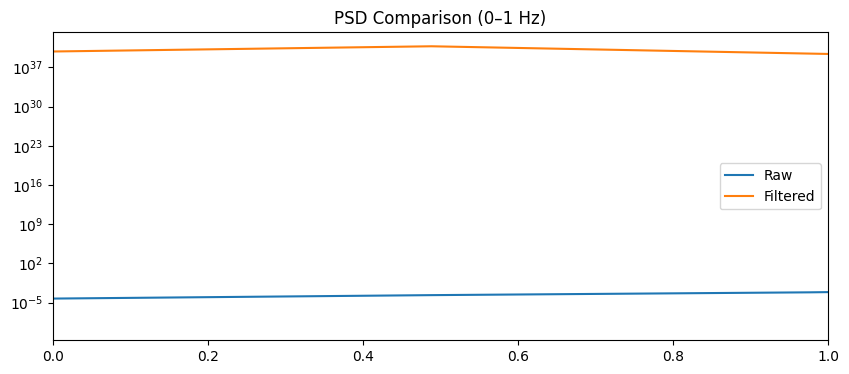

In [9]:
freqs_raw, psd_raw = welch(sample_signal, fs=fs)
freqs_filt, psd_filt = welch(filtered_signal, fs=fs)

plt.figure(figsize=(10,4))
plt.semilogy(freqs_raw, psd_raw, label='Raw')
plt.semilogy(freqs_filt, psd_filt, label='Filtered')
plt.xlim(0, 1)
plt.legend()
plt.title("PSD Comparison (0–1 Hz)")
plt.show()


In [10]:
X_filtered = []

for window in X:
    filtered = bandpass_filter(window, fs=fs)
    X_filtered.append(filtered)

X_filtered = np.array(X_filtered)

print(X_filtered.shape)


(1638, 3750)


In [11]:
# Make sure your base path exists
base_path = r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data"
save_path = os.path.join(base_path, "processed")
os.makedirs(save_path, exist_ok=True)

# Save X and y
np.save(os.path.join(save_path, "X_windows.npy"), X)
np.save(os.path.join(save_path, "y_labels.npy"), y)

print(f"Saved X_windows.npy and y_labels.npy to {save_path}")


Saved X_windows.npy and y_labels.npy to C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\processed


In [12]:
def estimate_rr_from_psd(signal, fs=125):
    freqs, psd = welch(signal, fs=fs, nperseg=1024)
    
    # focus only on respiration band
    mask = (freqs >= 0.1) & (freqs <= 0.4)
    
    freqs_band = freqs[mask]
    psd_band = psd[mask]
    
    dominant_freq = freqs_band[np.argmax(psd_band)]
    
    rr_bpm = dominant_freq * 60
    return rr_bpm


In [13]:
rr_predictions = []

for window in X_filtered:
    rr = estimate_rr_from_psd(window, fs=fs)
    rr_predictions.append(rr)

rr_predictions = np.array(rr_predictions)


In [14]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, rr_predictions)
print("Baseline PSD MAE:", mae)


Baseline PSD MAE: 10.057110424297925


In [15]:
from scipy.signal import find_peaks

def detect_r_peaks(signal, fs=125):
    # simple peak detection
    peaks, _ = find_peaks(signal, distance=fs*0.4)  # ~150 bpm max HR
    
    return peaks


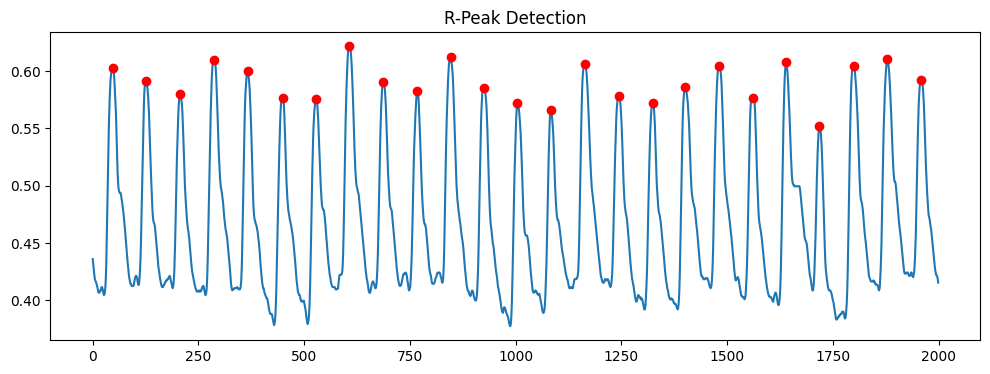

In [16]:
sample = X[0]
peaks = detect_r_peaks(sample, fs=fs)

plt.figure(figsize=(12,4))
plt.plot(sample[:2000])
plt.plot(peaks[peaks < 2000], sample[peaks[peaks < 2000]], "ro")
plt.title("R-Peak Detection")
plt.show()


In [17]:
def build_edr(signal, peaks):
    r_amplitudes = signal[peaks]
    return peaks, r_amplitudes


In [18]:
from scipy.interpolate import interp1d

def interpolate_edr(peaks, amplitudes, signal_length, fs=125):
    time_peaks = peaks / fs
    f_interp = interp1d(time_peaks, amplitudes, kind='cubic', fill_value="extrapolate")
    
    time_uniform = np.arange(signal_length) / fs
    edr_uniform = f_interp(time_uniform)
    
    return edr_uniform


In [19]:
def estimate_rr_from_edr(signal, fs=125):
    peaks = detect_r_peaks(signal, fs)
    if len(peaks) < 5:
        return np.nan
    
    peaks, amps = build_edr(signal, peaks)
    edr_signal = interpolate_edr(peaks, amps, len(signal), fs)
    
    freqs, psd = welch(edr_signal, fs=fs, nperseg=1024)
    
    mask = (freqs >= 0.1) & (freqs <= 0.4)
    if np.sum(mask) == 0:
        return np.nan
    
    dominant_freq = freqs[mask][np.argmax(psd[mask])]
    
    return dominant_freq * 60


In [20]:
rr_preds = []

for window in X:
    rr = estimate_rr_from_edr(window, fs=fs)
    rr_preds.append(rr)

rr_preds = np.array(rr_preds)

valid_mask = ~np.isnan(rr_preds)

mae = mean_absolute_error(y[valid_mask], rr_preds[valid_mask])
print("EDR Baseline MAE:", mae)


EDR Baseline MAE: 4.298503796550672


In [21]:
def estimate_rr_from_edr(signal, fs=125):
    peaks = detect_r_peaks(signal, fs)
    if len(peaks) < 5:
        return np.nan
    
    # Build EDR
    peaks, amps = build_edr(signal, peaks)
    edr_signal = interpolate_edr(peaks, amps, len(signal), fs)
    
    # Proper bandpass on EDR
    edr_filtered = bandpass_filter(edr_signal, lowcut=0.1, highcut=0.4, fs=fs, order=4)
    
    # PSD
    freqs, psd = welch(edr_filtered, fs=fs, nperseg=2048)
    
    mask = (freqs >= 0.1) & (freqs <= 0.4)
    if np.sum(mask) == 0:
        return np.nan
    
    dominant_freq = freqs[mask][np.argmax(psd[mask])]
    
    return dominant_freq * 60


In [22]:
rr_preds = []

for window in X:
    rr = estimate_rr_from_edr(window, fs=fs)
    rr_preds.append(rr)

rr_preds = np.array(rr_preds)

valid_mask = ~np.isnan(rr_preds)

mae = mean_absolute_error(y[valid_mask], rr_preds[valid_mask])
print("Improved EDR MAE:", mae)


Improved EDR MAE: 10.057110424297925


In [23]:
from scipy.signal import resample

def downsample_signal(signal, original_fs=125, target_fs=10):
    duration = len(signal) / original_fs
    num_samples = int(duration * target_fs)
    downsampled = resample(signal, num_samples)
    return downsampled


In [24]:
def estimate_rr_from_edr(signal, fs=125):
    peaks = detect_r_peaks(signal, fs)
    if len(peaks) < 5:
        return np.nan
    
    peaks, amps = build_edr(signal, peaks)
    edr_signal = interpolate_edr(peaks, amps, len(signal), fs)
    
    # ✅ Downsample to 10 Hz
    edr_down = downsample_signal(edr_signal, original_fs=fs, target_fs=10)
    
    # Now bandpass at new fs
    edr_filtered = bandpass_filter(edr_down, lowcut=0.1, highcut=0.4, fs=10, order=4)
    
    freqs, psd = welch(edr_filtered, fs=10, nperseg=256)
    
    mask = (freqs >= 0.1) & (freqs <= 0.4)
    if np.sum(mask) == 0:
        return np.nan
    
    freqs_band = freqs[mask]
    psd_band = psd[mask]
    
    # Use weighted centroid (more stable)
    dominant_freq = np.sum(freqs_band * psd_band) / np.sum(psd_band)
    
    return dominant_freq * 60


In [25]:
rr_preds = []

for window in X:
    rr = estimate_rr_from_edr(window, fs=fs)
    rr_preds.append(rr)

rr_preds = np.array(rr_preds)

valid_mask = ~np.isnan(rr_preds)

mae = mean_absolute_error(y[valid_mask], rr_preds[valid_mask])
print("Improved EDR MAE:", mae)


Improved EDR MAE: 3.419242135176161


In [26]:
def build_rr_interval_edr(signal, fs=125):
    peaks = detect_r_peaks(signal, fs)
    if len(peaks) < 5:
        return None
    
    rr_intervals = np.diff(peaks) / fs  # seconds
    
    # Use midpoints of RR intervals
    rr_times = peaks[:-1] / fs
    
    return rr_times, rr_intervals


In [27]:
def estimate_rr_from_rr_intervals(signal, fs=125):
    result = build_rr_interval_edr(signal, fs)
    if result is None:
        return np.nan
    
    rr_times, rr_intervals = result
    
    # Interpolate to uniform 10 Hz
    duration = len(signal) / fs
    time_uniform = np.arange(0, duration, 0.1)  # 10 Hz
    
    f_interp = interp1d(rr_times, rr_intervals, kind='cubic', fill_value="extrapolate")
    rr_uniform = f_interp(time_uniform)
    
    # Bandpass
    rr_filtered = bandpass_filter(rr_uniform, lowcut=0.1, highcut=0.4, fs=10, order=4)
    
    freqs, psd = welch(rr_filtered, fs=10, nperseg=256)
    
    mask = (freqs >= 0.1) & (freqs <= 0.4)
    if np.sum(mask) == 0:
        return np.nan
    
    freqs_band = freqs[mask]
    psd_band = psd[mask]
    
    dominant_freq = np.sum(freqs_band * psd_band) / np.sum(psd_band)
    
    return dominant_freq * 60


In [28]:
rr_preds_rri = []

for window in X:
    rr = estimate_rr_from_rr_intervals(window, fs=fs)
    rr_preds_rri.append(rr)

rr_preds_rri = np.array(rr_preds_rri)

valid_mask = ~np.isnan(rr_preds_rri)

mae_rri = mean_absolute_error(y[valid_mask], rr_preds_rri[valid_mask])
print("RR-Interval EDR MAE:", mae_rri)


RR-Interval EDR MAE: 4.68462465290152


In [29]:
combined = (rr_preds + rr_preds_rri) / 2

valid_mask = ~np.isnan(combined)

mae_combined = mean_absolute_error(y[valid_mask], combined[valid_mask])
print("Combined EDR MAE:", mae_combined)


Combined EDR MAE: 3.9585950313514866
